In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the capex sheet
df_capex = pd.read_excel("toy_results.xlsx", sheet_name="capex")

print(df_capex.head())

    technology                         item  investment
0  aquathermal             Water Collectors     26250.0
1  aquathermal  Water Pipes, fittings, etc.     12750.0
2  aquathermal                    E-Cabling      3750.0
3  aquathermal               Source-HP Pump    393925.0
4  aquathermal                   Pump House     25000.0


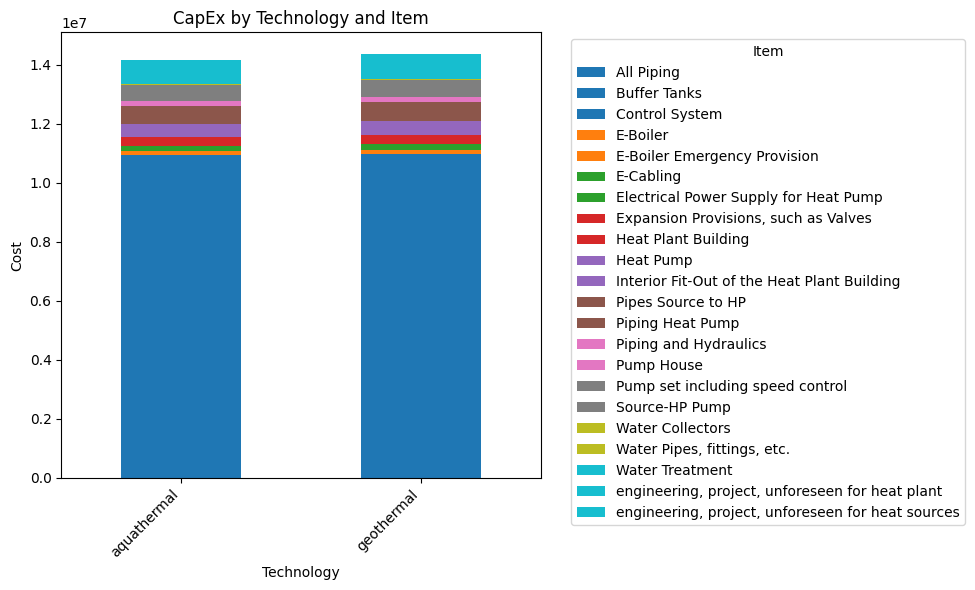

In [7]:
# Pivot: x-axis = technology, stacked segments = item, values = cost
pivot = df_capex.pivot_table(index="technology", columns="item", values="investment", aggfunc="sum")

# Plot stacked bar chart
ax = pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="tab10"
)

ax.set_title("CapEx by Technology and Item")
ax.set_xlabel("Technology")
ax.set_ylabel("Cost")
ax.legend(title="Item", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [15]:
# Load the capex sheet
df_toc = pd.read_excel("toy_results.xlsx", sheet_name="toc")

print(df_toc.head())

                      id   technology     toc   location
0    aquathermal_Enspijk  aquathermal  104000    Enspijk
1     geothermal_Enspijk   geothermal  107000    Enspijk
2            gas_Enspijk          gas   79000    Enspijk
3  aquathermal_Hilversum  aquathermal  100000  Hilversum
4   geothermal_Hilversum   geothermal  156000  Hilversum


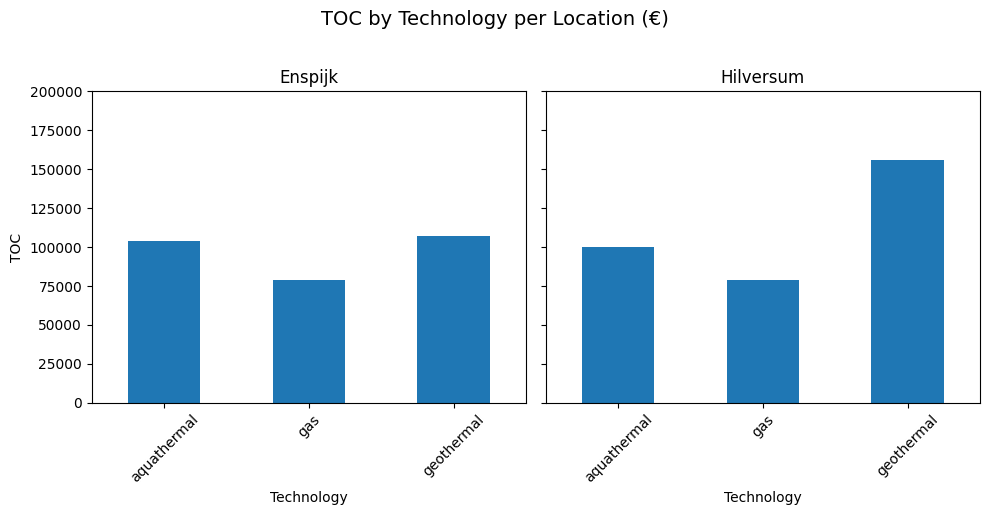

In [19]:
locations = df_toc["location"].unique()
n = len(locations)

fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), sharey=True)

if n == 1:
    axes = [axes]

for ax, loc in zip(axes, locations):
    subset = df_toc[df_toc["location"] == loc]
    pivot = subset.pivot_table(index="technology", values="toc", aggfunc="sum")

    pivot.plot(
        kind="bar",
        ax=ax,
        colormap="tab10",
        legend=False
    )

    ax.set_title(loc)
    ax.set_xlabel("Technology")
    ax.set_ylim(0, 200000)
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("TOC")
fig.suptitle("TOC by Technology per Location (\u20ac)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
## chart above is relevant to sensitivity analysis

In [ ]:
## include TCO and tariff per tech side by side, per tech.

In [ ]:
## box plot, tcos for different sensitivity scenarios, columns are sensitivity techs, highlight as baseline

In [ ]:
## dupe for tariff